# AlphaZero from Scratch — on Tic-Tac-Toe

A minimal but **complete** implementation of AlphaZero (Silver et al., *Science* 2018):
one neural network $f_\theta(s) \to (\mathbf p, v)$, **MCTS with PUCT** as the teacher,
and **self-play** as the data engine. Tabula rasa — no human games, no handcrafted evaluation.

Tic-tac-toe is tiny enough to train on a laptop CPU in minutes, but every moving part below
is the real algorithm:

- **PUCT selection:** $a^* = \arg\max_a\left[ Q(s,a) + c_{\text{puct}}\, P(s,a)\,
  \frac{\sqrt{N(s)}}{1+N(s,a)} \right]$
- **Dirichlet noise** on the root priors (exploration during self-play)
- **Temperature** move sampling: $a \sim \boldsymbol\pi^{1/\tau}$
- **Loss:** $\ell = (z-v)^2 - \boldsymbol\pi^\top \log \mathbf p + c\lVert\theta\rVert^2$
- **Replay buffer** + dihedral **symmetry augmentation**

**Roadmap:** game → network → MCTS → self-play → training → the policy-iteration loop →
evaluation → play a game against it.

> Runtime: a few minutes on CPU. The long cell (§6) prints progress as it goes.


In [1]:
import math, random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cpu")
print("device:", device, "| torch", torch.__version__)


device: cpu | torch 2.14.0+cpu


## 1. The game

Board: 3×3 `int8`, `1` = X, `-1` = O, `0` = empty. `player` is whoever moves next (`1` or `-1`).
Moves are integers `0..8` (row-major). This is the *environment* — the only place the rules live,
exactly like AlphaZero, which is given nothing but the rules.


In [2]:
class TicTacToe:
    def __init__(self):
        self.board = np.zeros((3, 3), dtype=np.int8)
        self.player = 1  # X moves first

    def clone(self):
        g = TicTacToe()
        g.board = self.board.copy()
        g.player = self.player
        return g

    @property
    def legal_moves(self):
        return [int(i) for i in range(9) if self.board.flat[i] == 0]

    def play(self, a):
        r, c = divmod(a, 3)
        assert self.board[r, c] == 0, "illegal move"
        self.board[r, c] = self.player
        self.player = -self.player

    def winner(self):
        b = self.board
        lines = ([b[i, :].sum() for i in range(3)] + [b[:, i].sum() for i in range(3)]
                 + [np.trace(b), np.trace(np.fliplr(b))])
        for s in lines:
            if abs(s) == 3:
                return int(np.sign(s))
        return 0

    @property
    def terminal(self):
        return self.winner() != 0 or not (self.board == 0).any()

    def __repr__(self):
        sym = {1: "X", -1: "O", 0: "."}
        rows = [" ".join(sym[v] for v in row) for row in self.board]
        return "\n".join(rows) + f"\nto move: {sym[self.player]}"


In [3]:
# sanity checks
g = TicTacToe()
assert g.legal_moves == list(range(9)) and not g.terminal
g.play(0); g.play(4); g.play(1); g.play(5); g.play(2)   # X takes the top row
assert g.winner() == 1 and g.terminal
print(g); print()

g2 = TicTacToe()
for a in [0, 1, 2, 4, 3, 5, 7, 6, 8]:                  # a forced draw
    g2.play(a)
assert g2.terminal and g2.winner() == 0
print(g2); print("\ngame logic OK")


X X X
. O O
. . .
to move: O

X O X
X O O
O X X
to move: O

game logic OK


## 2. The network $f_\theta(s) \to (\mathbf p, v)$

**Input** — the AlphaZero way: binary planes from the *player-to-move's* perspective,
so the net never has to learn "whose turn is it":
- plane 0: my stones, plane 1: opponent stones → shape `(2, 3, 3)`.

(Real AlphaZero stacks history planes too — 8 plies for chess — to capture repetitions.
Tic-tac-toe has no repetition rule, so 2 planes suffice.)

**Body** — a small ResNet: stem conv → residual blocks → **two heads**:
- *policy head*: 9 logits, one per square (illegal squares masked at use time);
- *value head*: scalar in $(-1, 1)$, the expected outcome for the player to move.

AlphaZero used 20–40 blocks × 256 filters. We use 2 × 32 — about 15k parameters.
Same architecture family, same two-headed job.


In [4]:
def encode(game):
    """(2,3,3) float32 planes, canonical: [own stones, opponent stones]."""
    p = game.player
    return np.stack([(game.board == p), (game.board == -p)]).astype(np.float32)


class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c1, self.bn1 = nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c)
        self.c2, self.bn2 = nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c)

    def forward(self, x):
        return F.relu(x + self.bn2(self.c2(F.relu(self.bn1(self.c1(x))))))


class AlphaZeroNet(nn.Module):
    def __init__(self, n_blocks=2, n_filters=32):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(2, n_filters, 3, padding=1, bias=False),
                                  nn.BatchNorm2d(n_filters), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlock(n_filters) for _ in range(n_blocks)])
        # policy head -> 9 move logits
        self.p_conv = nn.Conv2d(n_filters, 2, 1, bias=False)
        self.p_bn = nn.BatchNorm2d(2)
        self.p_fc = nn.Linear(2 * 9, 9)
        # value head -> scalar in (-1, 1)
        self.v_conv = nn.Conv2d(n_filters, 1, 1, bias=False)
        self.v_bn = nn.BatchNorm2d(1)
        self.v_fc1 = nn.Linear(9, 32)
        self.v_fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.blocks(self.stem(x))
        p = self.p_fc(F.relu(self.p_bn(self.p_conv(x))).flatten(1))
        v = torch.tanh(self.v_fc2(F.relu(self.v_fc1(
            F.relu(self.v_bn(self.v_conv(x))).flatten(1))))).squeeze(1)
        return p, v


net = AlphaZeroNet().to(device)
n_params = sum(p.numel() for p in net.parameters())
print(f"parameters: {n_params:,}")

x = torch.from_numpy(encode(TicTacToe())).unsqueeze(0)
logits, v = net(x)
print("logits shape:", tuple(logits.shape), "| value:", round(float(v[0]), 3),
      "(random net — meaningless, as it should be at init)")


parameters: 38,386


logits shape: (1, 9) | value: -0.038 (random net — meaningless, as it should be at init)


/tmp/ipykernel_3294/651739727.py:47: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  print("logits shape:", tuple(logits.shape), "| value:", round(float(v[0]), 3),


## 3. MCTS with PUCT — the expensive teacher

This is the answer to *"do the 800 simulations share one policy?"*: **the network is frozen**
during a search. What evolves across simulations is the **tree** — visit counts $N$ and
mean values $Q$. Each simulation:

1. **Select** — descend with PUCT:
   $a^* = \arg\max_a\left[ Q(s,a) + c_{\text{puct}}\, P(s,a)\,
   \frac{\sqrt{N(s)}}{1+N(s,a)} \right]$.
   $P$ is the *frozen* net prior; the $\sqrt{N}/(1+N)$ term drags search toward underexplored moves.
2. **Expand** — at the leaf, **one** network evaluation gives priors $P(s,\cdot)$ and value $v$.
   No rollout to game end — the network *is* the evaluation function (this was AlphaZero's
   break from AlphaGo).
3. **Backup** — propagate $v$ up, negating at each level (zero-sum: what's good for me is bad for you).

After $N_{\text{sims}}$ simulations the move distribution is
$\pi_a \propto N(s,a)^{1/\tau}$. That $\boldsymbol\pi$ — strictly stronger than the raw
$\mathbf p$ — becomes the **training target**. The net learns to imitate its own search:
*policy improvement*, distilled.

Exploration during self-play comes from **Dirichlet noise** injected once into the root priors:
$P \leftarrow (1-\varepsilon)P + \varepsilon\,\mathrm{Dir}(\alpha)$.


In [5]:
class Node:
    __slots__ = ("game", "prior", "N", "W", "children", "prior_vec", "expanded")
    def __init__(self, game, prior=0.0):
        self.game = game          # position; game.player is to move
        self.prior = prior        # P(s,a) from the parent's expansion
        self.N, self.W = 0, 0.0   # visits, total value (player-to-move perspective)
        self.children = {}
        self.prior_vec = None
        self.expanded = False


def masked_probs(logits, legal):
    p = np.zeros(9)
    p[legal] = np.exp(logits[legal] - logits[legal].max())
    return p / p.sum()


@torch.no_grad()
def net_eval(net, game):
    net.eval()
    x = torch.from_numpy(encode(game)).unsqueeze(0).to(device)
    logits, v = net(x)
    return logits[0].cpu().numpy(), float(v[0])


def expand_node(node, net):
    logits, v = net_eval(net, node.game)
    node.prior_vec = masked_probs(logits, node.game.legal_moves)
    node.expanded = True
    return v  # value from the perspective of node.game.player


def select_child(node, c_puct):
    best_a, best_score = None, -1e18
    for a in node.game.legal_moves:
        child = node.children.get(a)
        if child is None:
            q, n, p = 0.0, 0, node.prior_vec[a]
        else:
            # child.W is from the *opponent's* perspective -> negate for us
            q, n, p = (-child.W / child.N if child.N else 0.0), child.N, child.prior
        score = q + c_puct * p * math.sqrt(node.N) / (1 + n)
        if score > best_score:
            best_a, best_score = a, score
    return best_a


def run_mcts(game, net, n_sims, c_puct=1.5, add_noise=True,
             dirichlet_alpha=0.3, dirichlet_eps=0.25):
    """Returns raw visit counts over the 9 actions for `game`'s position."""
    root = Node(game.clone())
    expand_node(root, net)
    if add_noise:  # once, before simulation 1 — not re-sampled per sim
        legal = game.legal_moves
        noise = np.random.dirichlet([dirichlet_alpha] * len(legal))
        for i, a in enumerate(legal):
            root.prior_vec[a] = (1 - dirichlet_eps) * root.prior_vec[a] + dirichlet_eps * noise[i]

    for _ in range(n_sims):
        node, path = root, [root]
        while node.expanded and not node.game.terminal:
            a = select_child(node, c_puct)
            child = node.children.get(a)
            if child is None:
                g = node.game.clone(); g.play(a)
                child = Node(g, prior=node.prior_vec[a])
                node.children[a] = child
            node = child
            path.append(node)
        if node.game.terminal:  # player to move is the loser (or draw)
            w = node.game.winner()
            v = 1.0 if w == node.game.player else (-1.0 if w == -node.game.player else 0.0)
        else:
            v = expand_node(node, net)
        for nd in reversed(path):  # backup with zero-sum negation
            nd.N += 1
            nd.W += v
            v = -v
    return np.array([root.children[a].N if a in root.children else 0
                     for a in range(9)], dtype=float)


In [6]:
# What does a search look like before any learning? Random net + Dirichlet noise.
demo = AlphaZeroNet().to(device)
counts = run_mcts(TicTacToe(), demo, n_sims=200, add_noise=True)
print("visit counts, empty board (random net, Dirichlet noise on):")
print(counts.reshape(3, 3).astype(int))
print("\nNote: visits spread around — noise forces the tree to try moves the net ignores.")


visit counts, empty board (random net, Dirichlet noise on):
[[16 23 21]
 [28 22 21]
 [22 26 21]]

Note: visits spread around — noise forces the tree to try moves the net ignores.


## 4. Self-play — manufacturing $(s, \boldsymbol\pi, z)$

One self-play game: at every position run MCTS ($N_{\text{sims}}$ sims, noise on,
temperature $\tau=1$ sampling), record `(encode(s), π, player)`, play the sampled move.
When the game ends, attach $z$: $+1$ if *that position's* player eventually won,
$-1$ if they lost, $0$ for a draw.

Each game costs `moves × n_sims` network evals to produce a handful of training examples —
the most expensive labeling function in ML, and the labels beat anything human.

**Symmetry augmentation:** tic-tac-toe positions have 8 dihedral symmetries; we apply a random
one to $(s, \boldsymbol\pi)$ at train time — free 8× data, exactly as AlphaZero did for Go.


In [7]:
def self_play_game(net, n_sims, c_puct=1.5, temperature=1.0):
    game = TicTacToe()
    states, pis, players = [], [], []
    while not game.terminal:
        counts = run_mcts(game, net, n_sims, c_puct, add_noise=True)
        pi = counts ** (1.0 / temperature)
        pi = pi / pi.sum()
        states.append(encode(game)); pis.append(pi); players.append(game.player)
        game.play(int(np.random.choice(9, p=pi)))
    w = game.winner()
    z = [1.0 if w == p else (-1.0 if w == -p else 0.0) for p in players]
    return list(zip(states, pis, z))


def augment(s, pi):
    """Random dihedral symmetry applied jointly to board planes and policy."""
    k = np.random.randint(8)
    b, p = s.reshape(2, 3, 3).copy(), pi.reshape(3, 3).copy()
    if k >= 4:
        b, p, k = b[:, :, ::-1].copy(), p[:, ::-1].copy(), k - 4
    b = np.rot90(b, k, axes=(1, 2)).copy()
    p = np.rot90(p, k).copy()
    return b.reshape(2, 3, 3), p.reshape(9)


# demo: one game with the untrained net
demo_game = self_play_game(AlphaZeroNet().to(device), n_sims=30)
print(f"one self-play game -> {len(demo_game)} training examples")
s0, pi0, z0 = demo_game[0]
print("first position's pi (3x3):\n", np.round(pi0.reshape(3, 3), 3))
print("its z:", z0)


one self-play game -> 9 training examples
first position's pi (3x3):
 [[0.267 0.1   0.133]
 [0.067 0.067 0.067]
 [0.133 0.1   0.067]]
its z: 0.0


## 5. Training — distilling the search into the net

Loss on a batch: $\ell = \underbrace{(z-v)^2}_{\text{value: predict the outcome}} + \underbrace{(-\boldsymbol\pi^\top \log \mathbf p)}_{\text{policy: imitate the search}} + \underbrace{c\lVert\theta\rVert^2}_{\text{weight decay}}$.

The crucial subtlety: the policy target is $\boldsymbol\pi$ (MCTS visits), **not** the net's
own raw $\mathbf p$. The student is trained to imitate the teacher — and the teacher *is*
the student plus search. Next iteration the priors are better, the search aims better,
$\boldsymbol\pi$ gets stronger: the ratchet of generalized policy iteration.


In [8]:
def train(net, opt, buffer, batch_size=256, epochs=4):
    net.train()
    data = list(buffer)
    tot_p = tot_v = n = 0.0
    for _ in range(epochs):
        random.shuffle(data)
        for i in range(0, len(data), batch_size):
            batch = data[i:i + batch_size]
            ss, pp, zz = [], [], []
            for st, pi, z in batch:
                a_st, a_pi = augment(st, pi)
                ss.append(a_st); pp.append(a_pi); zz.append(z)
            s = torch.tensor(np.stack(ss), dtype=torch.float32).to(device)
            pt = torch.tensor(np.stack(pp), dtype=torch.float32).to(device)
            zt = torch.tensor(zz, dtype=torch.float32).to(device)
            logits, v = net(s)
            loss_p = -(pt * F.log_softmax(logits, dim=1)).sum(1).mean()
            loss_v = F.mse_loss(v, zt)
            (loss_p + loss_v).backward()
            opt.step(); opt.zero_grad()
            tot_p += float(loss_p); tot_v += float(loss_v); n += 1
    return tot_p / n, tot_v / n


## 6. The main loop — generalized policy iteration

Repeat: **self-play** with the current net → **train** on the replay buffer → the net improves →
self-play gets stronger. (AlphaZero dropped AlphaGo's 55%-win-rate gating: no tournament between
old and new nets, just continuous training on the newest weights.)

| | AlphaZero (paper) | this notebook |
|---|---|---|
| sims / move (self-play) | 800 | 60 |
| network | 20–40 res blocks × 256 filters | 2 × 32 (~15k params) |
| self-play compute | 5,000 TPUs | 1 laptop CPU |
| training | 700k steps × 4096 positions | ~12 iters × 30 games |
| Dirichlet $\alpha$ / $\varepsilon$ | 0.3 / 0.25 (chess) | 0.3 / 0.25 |
| $c_{\text{puct}}$ | tuned constant | 1.5 |

Evaluation: the agent (MCTS, no noise, greedy) vs a uniform-random player, alternating colors.
Score = wins + ½·draws. Optimal tic-tac-toe never loses — watch it get there.

Plus, after **every** iteration the net spars against perfect play — the memoized minimax
oracle defined just below, 9 forced openings per color. Any loss there is a proven blunder.


### A perfect sparring partner, checked every iteration

Tic-tac-toe is solved: perfect play always draws. The memoized minimax oracle below
plays perfectly, so the training loop spars against it **after every iteration** and
tracks the result — watch the blunders disappear as the net converges. Any loss is a
proven blunder, since perfect play guarantees at least a draw.

In [9]:
# Minimax oracle: perfect tic-tac-toe play (memoized).
# Value is from X's perspective: +1 X wins, -1 O wins, 0 draw.
from functools import lru_cache

def _bkey(board, player):
    return (tuple(np.asarray(board).flat), player)

@lru_cache(maxsize=None)
def _minimax_value(key):
    bt, player = key
    b = np.array(bt, dtype=np.int8).reshape(3, 3)
    lines = ([b[i, :].sum() for i in range(3)] + [b[:, i].sum() for i in range(3)]
             + [np.trace(b), np.trace(np.fliplr(b))])
    for s in lines:
        if abs(s) == 3:
            return int(np.sign(s))
    moves = [i for i in range(9) if bt[i] == 0]
    if not moves:
        return 0
    vals = []
    for a in moves:
        lst = list(bt); lst[a] = player
        vals.append(_minimax_value((tuple(lst), -player)))
    return max(vals) if player == 1 else min(vals)

def minimax_move(game):
    """Optimal move for the player to move (deterministic: lowest index wins ties)."""
    best_a, best_v = None, (-1e9 if game.player == 1 else 1e9)
    for a in game.legal_moves:
        g = game.clone(); g.play(a)
        v = _minimax_value(_bkey(g.board, g.player))
        if (game.player == 1 and v > best_v) or (game.player == -1 and v < best_v):
            best_a, best_v = a, v
    return best_a

# sanity: with perfect play from the empty board, tic-tac-toe is a draw
assert _minimax_value(_bkey(np.zeros((3, 3), np.int8), 1)) == 0
print("minimax oracle OK: perfect play from the empty board = draw")


def mcts_greedy_move(game, net, n_sims=60):
    counts = run_mcts(game, net, n_sims, add_noise=False)
    return int(np.random.choice(np.flatnonzero(counts == counts.max())))

def evaluate_vs_perfect(net, n_sims=60):
    """Net (MCTS, no noise, greedy) vs the minimax oracle, 9 forced openings per color.
    Any loss is a proven blunder: perfect play guarantees at least a draw,
    so losing means the net threw away a drawable game."""
    res = {"as_X": [0, 0, 0], "as_O": [0, 0, 0]}  # [wins, draws, losses] from net's view
    for opening in range(9):
        for net_color, tag in ((1, "as_X"), (-1, "as_O")):
            game = TicTacToe()
            game.play(opening)  # forced first move, then both sides play for real
            while not game.terminal:
                if game.player == net_color:
                    a = mcts_greedy_move(game, net, n_sims)
                else:
                    a = minimax_move(game)
                game.play(a)
            w = game.winner()
            res[tag][0 if w == net_color else (1 if w == 0 else 2)] += 1
    return res


minimax oracle OK: perfect play from the empty board = draw


In [10]:
def evaluate(net, n_games=20, n_sims=60):
    """Agent (MCTS, no noise, greedy) vs uniform-random. Returns score in [0,1]."""
    score = 0.0
    for i in range(n_games):
        game, agent = TicTacToe(), (1 if i % 2 == 0 else -1)
        while not game.terminal:
            if game.player == agent:
                counts = run_mcts(game, net, n_sims, add_noise=False)
                a = int(np.random.choice(np.flatnonzero(counts == counts.max())))
            else:
                a = random.choice(game.legal_moves)
            game.play(a)
        w = game.winner()
        score += 1.0 if w == agent else (0.5 if w == 0 else 0.0)
    return score / n_games


N_ITERS, GAMES_PER_ITER, N_SIMS = 12, 30, 60
net = AlphaZeroNet().to(device)
opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
buffer = deque(maxlen=6000)
hist = {"policy_loss": [], "value_loss": [], "score": [],
        "perfect_w": [], "perfect_d": [], "perfect_l": []}

print(f"{'iter':>4} | {'positions':>9} | {'pol_loss':>8} | {'val_loss':>8} | {'vs random':>9} | {'vs perfect':>11}")
for it in range(N_ITERS):
    for _ in range(GAMES_PER_ITER):
        buffer.extend(self_play_game(net, N_SIMS))
    pl, vl = train(net, opt, buffer)
    sc = evaluate(net)
    r = evaluate_vs_perfect(net)  # 18 games vs the minimax oracle
    w = r["as_X"][0] + r["as_O"][0]; d = r["as_X"][1] + r["as_O"][1]; l = r["as_X"][2] + r["as_O"][2]
    hist["policy_loss"].append(pl); hist["value_loss"].append(vl); hist["score"].append(sc)
    hist["perfect_w"].append(w); hist["perfect_d"].append(d); hist["perfect_l"].append(l)
    print(f"{it+1:>4} | {len(buffer):>9} | {pl:>8.4f} | {vl:>8.4f} | {sc:>9.3f} | {w}W {d}D {l}L", flush=True)

print("\ndone. Final score vs random:", round(hist["score"][-1], 3))
w, d, l = hist["perfect_w"][-1], hist["perfect_d"][-1], hist["perfect_l"][-1]
print(f"Final vs perfect play: {w}W {d}D {l}L",
      "-- no losses, the net never blundered a drawable game" if l == 0 else
      f"-- {l} LOSS(ES): the net threw away drawn positions")


iter | positions | pol_loss | val_loss | vs random |  vs perfect


   1 |       217 |   2.2215 |   0.6801 |     0.950 | 0W 7D 11L


   2 |       417 |   2.1179 |   0.6827 |     0.900 | 0W 8D 10L


   3 |       632 |   2.0203 |   0.6087 |     0.900 | 0W 11D 7L


   4 |       843 |   1.9336 |   0.6126 |     1.000 | 0W 13D 5L


...

   9 |      1949 |   1.5309 |   0.4369 |     0.975 | 0W 17D 1L


  10 |      2185 |   1.4639 |   0.4145 |     0.975 | 0W 18D 0L


  11 |      2417 |   1.4067 |   0.3916 |     0.975 | 0W 18D 0L


  12 |      2659 |   1.3623 |   0.3716 |     0.975 | 0W 18D 0L



done. Final score vs random: 0.975
Final vs perfect play: 0W 18D 0L -- no losses, the net never blundered a drawable game


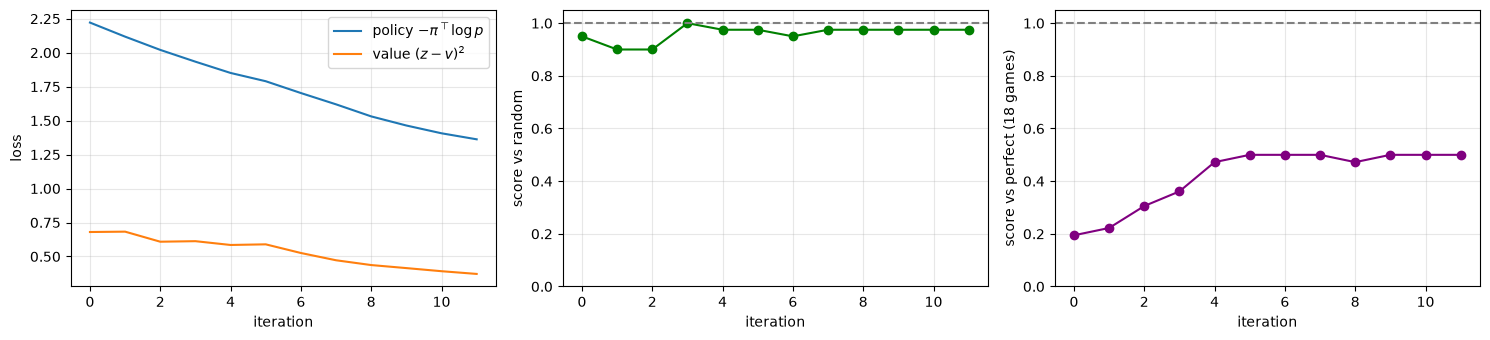

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].plot(hist["policy_loss"], label="policy $-\\pi^\\top\\log p$")
ax[0].plot(hist["value_loss"], label="value $(z-v)^2$")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(hist["score"], marker="o", color="green")
ax[1].axhline(1.0, ls="--", color="gray")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("score vs random")
ax[1].set_ylim(0, 1.05); ax[1].grid(alpha=0.3)
perfect_score = [(w + 0.5 * d) / 18 for w, d in zip(hist["perfect_w"], hist["perfect_d"])]
ax[2].plot(perfect_score, marker="o", color="purple")
ax[2].axhline(1.0, ls="--", color="gray")
ax[2].set_xlabel("iteration"); ax[2].set_ylabel("score vs perfect (18 games)")
ax[2].set_ylim(0, 1.05); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 7. What did it learn?

Two probes of the trained net (MCTS *off* — pure $\mathbf p$ and $v$, no search):
1. **Empty board policy** — optimal tic-tac-toe starts center or corner. Does the net know?
2. **A must-block tactic** — X threatens the top row; O *must* play square 2. Raw policy, no search.
3. **Value head** on a position where X wins next move.


In [12]:
def show_pi(game, net, title):
    logits, v = net_eval(net, game)
    pi = masked_probs(logits, game.legal_moves)
    print(f"{title}  (value head: {v:+.2f})")
    print(np.round(pi.reshape(3, 3), 3), "\n")

show_pi(TicTacToe(), net, "empty board policy")

g = TicTacToe()
g.board = np.array([[1, 1, 0], [-1, 0, 0], [0, 0, 0]], dtype=np.int8)  # X threatens top row
g.player = -1                                                          # O to move: must block at 2
print(g); print()
show_pi(g, net, "must-block policy (O to move)")

g2 = TicTacToe()
g2.board = np.array([[1, 1, 0], [-1, -1, 0], [0, 0, 1]], dtype=np.int8)
g2.player = 1   # X plays 2 and wins
_, v2 = net_eval(net, g2)
print(f"value when X is one move from winning: {v2:+.2f}  (want ≈ +1)")


empty board policy  (value head: +0.35)
[[0.109 0.111 0.114]
 [0.091 0.145 0.113]
 [0.099 0.106 0.111]] 

X X .
O . .
. . .
to move: O

must-block policy (O to move)  (value head: -0.48)
[[0.    0.    0.334]
 [0.    0.195 0.102]
 [0.045 0.142 0.182]] 

value when X is one move from winning: +0.77  (want ≈ +1)


## 8. Play against it

Set `INTERACTIVE = True` and re-run this cell to play in the notebook.
You are X and move first; the agent (O) thinks with 200 MCTS simulations per move.
Enter moves as 0–8:

```
0 1 2
3 4 5
6 7 8
```


In [13]:
INTERACTIVE = False  # <- set to True and re-run to play

def print_board(game):
    sym = {1: "X", -1: "O", 0: "."}
    print("\n".join(" ".join(sym[v] for v in row) for row in game.board), "\n")

def play_vs_agent(net, n_sims=200):
    game, human = TicTacToe(), 1
    while not game.terminal:
        print_board(game)
        if game.player == human:
            a = int(input("your move (0-8): "))
            assert a in game.legal_moves, "illegal!"
        else:
            counts = run_mcts(game, net, n_sims, add_noise=False)
            a = int(np.random.choice(np.flatnonzero(counts == counts.max())))
            print(f"agent plays {a}")
        game.play(a)
    print_board(game)
    w = game.winner()
    print("you win!" if w == human else ("draw." if w == 0 else "agent wins."))

if INTERACTIVE:
    play_vs_agent(net)
else:
    print("set INTERACTIVE = True and re-run this cell to play.")


set INTERACTIVE = True and re-run this cell to play.


## 9. Where to go next — experiments worth running

- **Connect Four.** Swap the `TicTacToe` class for 6×7 gravity Connect Four, widen the net
  (more filters/blocks), raise `N_SIMS`. Same loop, real game.
- **Kill the Dirichlet noise** (`dirichlet_eps=0`) and watch self-play collapse into repetitive
  lines — the exploration term is load-bearing.
- **$c_{\text{puct}}$ sweep** (0.5 / 1.5 / 5): too low → search trusts a bad net blindly;
  too high → search ignores what the net learned.
- **Ablate the teacher:** train the policy head on *game outcomes only* (no MCTS targets)
  and compare — this isolates what the 60-sim search buys you per datapoint.
- **Temperature:** self-play with $\tau \to 0$ (always greedy) vs $\tau=1$; watch diversity
  and final strength diverge.
- **Scale the net** and count how strength-vs-compute trades off — the small-scale version
  of the scaling story behind the original result.


In [14]:
# Final report card — read straight off the per-iteration history.
# (No need to re-run: the last training iteration already sparred 18 games vs the oracle.)
w, d, l = hist["perfect_w"][-1], hist["perfect_d"][-1], hist["perfect_l"][-1]
print(f"After {N_ITERS} iterations — vs perfect play (18 games): {w}W {d}D {l}L")
print("verdict:", "no losses -- the net never blundered a drawable game" if l == 0
      else f"{l} LOSS(ES) -- the net threw away drawn positions")


After 12 iterations — vs perfect play (18 games): 0W 18D 0L
verdict: no losses -- the net never blundered a drawable game
